# ENERGIZE - Model Evaluation (PyTorch)

This notebook covers:
1. **Model Loading**: Load trained model from checkpoint
2. **Inference**: Generate predictions on test data
3. **Metrics Calculation**: MAE, F1, Precision, Recall, Accuracy
4. **Visualization**: Prediction plots and confusion analysis
5. **Error Analysis**: Detailed error distribution analysis

---

## Google Colab Setup

**Before running this notebook on Colab:**
1. Upload your OpenNILM folder to Google Drive
2. Make sure training is complete and checkpoint exists
3. Run the setup cells below

---

## 0. Google Colab Setup (Run these cells first!)

In [145]:
# ============================================================================
# COLAB SETUP - Run this cell first!
# ============================================================================
import sys

# Detect if running on Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')


    # =========================================================================
    # CONFIGURE YOUR GOOGLE DRIVE PATH HERE
    # =========================================================================
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL'  # <-- EDIT THIS PATH
    # =========================================================================

    import os
    from pathlib import Path

    project_root = Path(DRIVE_PROJECT_PATH)

    if not project_root.exists():
        print(f"ERROR: Project folder not found at: {project_root}")
        print(f"Please upload OpenNILM to Google Drive or edit DRIVE_PROJECT_PATH above")
        print(f"\nYour Drive contents:")
        !ls "/content/drive/MyDrive/" | head -15
    else:
        os.chdir(project_root)
        sys.path.insert(0, str(project_root))
        print(f"Project root: {project_root}")
        print(f"Working directory: {os.getcwd()}")
else:
    import os
    from pathlib import Path
    project_root = Path(os.getcwd()).parent
    sys.path.insert(0, str(project_root))
    print(f"Running locally. Project root: {project_root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL
Working directory: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL


## 1. Setup and Imports

In [146]:
# ============================================================================
# IMPORTS
# ============================================================================
# Note: os, sys, Path, and project_root are already set up in the Colab setup cells above

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from tqdm import tqdm

# PyTorch NILM modules
from src_pytorch import (
    CNN_NILM, TCN_NILM, get_model,
    SimpleNILMDataLoader,
    SimpleTester,
    set_seeds, get_device, count_parameters,
    compute_status,
    compute_metrics,
)
from src_pytorch.config import get_training_config
from src_pytorch.models.cnn_seq2seq import CNN_NILM_Seq2Seq
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [147]:
# Set seeds and get device
set_seeds(42)
device = get_device()

Seeds set to 42
Using GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.09 GB


## 2. Configuration

**Important**: Make sure these match the settings used during training!

In [163]:
# ============================================
# CONFIGURATION - Must match training settings
# ============================================

# Dataset configuration
DATASET_NAME = 'plegma'          # 'refit' or 'plegma'
APPLIANCE_NAME = 'ac_1'          # washing_machine, ac_1, boiler

# Model configuration
MODEL_NAME = 'cnn_seq2seq'               # 'cnn', 'cnn_seq2seq', or 'wavenet_tcn'

# Model-specific parameters
MODEL_CONFIGS = {
    'cnn': {
        'input_window_length': 299,
        'batch_size': 1024
    },
    'cnn_seq2seq': {
        'input_window_length': 299,
        'batch_size': 512
    },
    'wavenet_tcn': {
        'input_window_length': 600,
        'batch_size': 128,
        'depth': 9,
        'nb_filters': [512, 360, 360, 256, 256, 256, 360, 360, 512],
        'dropout': 0.2,
        'stacks': 1
    }
}

# REFIT appliance parameters
REFIT_PARAMS = {
    'dishwasher':      {'threshold': 10,   'cutoff': 2500, 'mean': 602.55, 'std': 828.11},
    'washing_machine': {'threshold': 20,   'cutoff': 2500, 'mean': 512.30, 'std': 816.25},
    'kettle':          {'threshold': 2000, 'cutoff': 3000, 'mean': 500.10, 'std': 749.24},
    'microwave':       {'threshold': 200,  'cutoff': 1300, 'mean': 489.55, 'std': 696.09},
    'refrigerator':    {'threshold': 5,    'cutoff': 1700, 'mean': 600.18, 'std': 944.55},
}

# PLEGMA appliance parameters  (keep in sync with src_pytorch/config.py)
PLEGMA_PARAMS = {
    'ac_1':            {'threshold': 50,  'cutoff': 2300, 'mean': 345.71, 'std': 723.03, 'min_on': 100, 'min_off':  50},
    'boiler':          {'threshold': 800, 'cutoff': 4000, 'mean': 347.59, 'std': 745.19, 'min_on':  30, 'min_off':   6},
    'washing_machine': {'threshold': 15,  'cutoff': 2600, 'mean': 344.49, 'std': 731.61, 'min_on':   2, 'min_off': 100, 'min_committed_duration': 250},
    'fridge':          {'threshold': 50,  'cutoff':  400, 'mean': 328.16, 'std': 710.16, 'min_on':  10, 'min_off':   2},
}

# Select appropriate parameters based on dataset
APPLIANCE_PARAMS = REFIT_PARAMS if DATASET_NAME == 'refit' else PLEGMA_PARAMS

# Resolve all per-appliance values from config — no manual overrides needed
THRESHOLD  = APPLIANCE_PARAMS[APPLIANCE_NAME]['threshold']
CUTOFF     = APPLIANCE_PARAMS[APPLIANCE_NAME]['cutoff']
MIN_ON     = APPLIANCE_PARAMS[APPLIANCE_NAME].get('min_on')
MIN_OFF    = APPLIANCE_PARAMS[APPLIANCE_NAME].get('min_off')
MAX_LENGTH = APPLIANCE_PARAMS[APPLIANCE_NAME].get('min_committed_duration')

# Paths
DATA_DIR        = project_root / 'data' / 'processed' / DATASET_NAME / APPLIANCE_NAME
OUTPUT_DIR      = project_root / 'outputs' / f'{MODEL_NAME}_{APPLIANCE_NAME}'
CHECKPOINT_PATH = OUTPUT_DIR / 'checkpoint' / 'model.pt'

# Get model-specific config
model_config        = MODEL_CONFIGS[MODEL_NAME]
INPUT_WINDOW_LENGTH = model_config['input_window_length']
BATCH_SIZE          = model_config['batch_size']

print(f"Dataset:   {DATASET_NAME}")
print(f"Appliance: {APPLIANCE_NAME}")
print(f"Model:     {MODEL_NAME}")
print(f"Input window length: {INPUT_WINDOW_LENGTH}")
print(f"Threshold: {THRESHOLD} W  |  Cutoff: {CUTOFF} W")
if MIN_ON is not None:
    print(f"Min ON: {MIN_ON} samples  |  Min OFF: {MIN_OFF} samples", end='')
    print(f"  |  Max length: {MAX_LENGTH} samples" if MAX_LENGTH else "")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Dataset:   plegma
Appliance: ac_1
Model:     cnn_seq2seq
Input window length: 299
Threshold: 50 W  |  Cutoff: 2300 W
Min ON: 100 samples  |  Min OFF: 50 samples
Checkpoint: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/cnn_seq2seq_ac_1/checkpoint/model.pt


## 3. Load Model and Data

In [164]:
# Create the model
if MODEL_NAME == 'cnn':
    model = CNN_NILM(input_window_length=INPUT_WINDOW_LENGTH)
elif MODEL_NAME == 'wavenet_tcn':
    model = TCN_NILM(
        input_window_length=INPUT_WINDOW_LENGTH,
        depth=model_config.get('depth', 9),
        nb_filters=model_config.get('nb_filters'),
        dropout=model_config.get('dropout', 0.1),
        stacks=model_config.get('stacks', 1)
    )
elif MODEL_NAME == 'cnn_seq2seq':
    model = CNN_NILM_Seq2Seq(input_window_length=INPUT_WINDOW_LENGTH)

# Load weights
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model = model.to(device)
model.eval()

print(f"Model loaded from: {CHECKPOINT_PATH}")
print(f"Total parameters: {count_parameters(model):,}")

Model loaded from: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/cnn_seq2seq_ac_1/checkpoint/model.pt
Total parameters: 14,168,899


In [165]:
# Load data

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/ENERGIZE') / 'data' / 'processed' / DATASET_NAME / APPLIANCE_NAME

data_loader = SimpleNILMDataLoader(
    data_dir=str(DATA_DIR),
    model_name=MODEL_NAME,
    batch_size=BATCH_SIZE,
    input_window_length=INPUT_WINDOW_LENGTH,
    train=True,
    num_workers=0
)

test_loader = data_loader.test

print(f"Test batches: {len(test_loader)}")
print(f"Test data shape: {data_loader.test_data.shape}")
print(f"Test labels shape: {data_loader.test_labels.shape}")

Test batches: 25
Test data shape: (3798581,)
Test labels shape: (3798581,)


## 4. Generate Predictions

In [166]:
device

device(type='cuda')

In [167]:
@torch.no_grad()
def predict(model, data_loader, device):
    """Generate predictions for all data in the loader."""
    model.eval()
    predictions = []

    for batch_x, _ in tqdm(data_loader, desc="Generating predictions"):
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        predictions.append(outputs.cpu().numpy())

    return np.concatenate(predictions).flatten()

# Generate predictions
predictions_normalized = predict(model, test_loader, device)
print(f"Predictions shape: {predictions_normalized.shape}")

Generating predictions: 100%|██████████| 25/25 [00:00<00:00, 77.57it/s]

Predictions shape: (3798496,)


In [168]:
# Align ground truth with predictions based on model type
ground_truth_normalized = data_loader.test_labels.copy()

if MODEL_NAME == 'cnn':
    offset = int(INPUT_WINDOW_LENGTH / 2) - 1
    ground_truth_normalized = ground_truth_normalized[offset:]
    ground_truth_normalized = ground_truth_normalized[:len(predictions_normalized)]
else:  # tcn / cnn_seq2seq — full sequence output
    ground_truth_normalized = ground_truth_normalized[:len(predictions_normalized)]

print(f"Aligned ground truth shape: {ground_truth_normalized.shape}")
print(f"Predictions shape: {predictions_normalized.shape}")

Aligned ground truth shape: (3798496,)
Predictions shape: (3798496,)


In [169]:
# Denormalize to actual power values
ground_truth = ground_truth_normalized * CUTOFF
predictions = predictions_normalized * CUTOFF

# Apply threshold and clipping
predictions_clipped = predictions.copy()
predictions_clipped[predictions_clipped < THRESHOLD] = 0
predictions_clipped[predictions_clipped > CUTOFF] = CUTOFF

print(f"Ground truth range: [{ground_truth.min():.2f}, {ground_truth.max():.2f}] W")
print(f"Predictions range: [{predictions_clipped.min():.2f}, {predictions_clipped.max():.2f}] W")

Ground truth range: [0.00, 1598.17] W
Predictions range: [0.00, 1878.08] W


## 5. Calculate Metrics

In [170]:
metrics = compute_metrics(
    ground_truth, predictions_clipped, THRESHOLD,
    min_on=MIN_ON, min_off=MIN_OFF, min_committed_duration=MAX_LENGTH,
)

print("=" * 60)
print("EVALUATION METRICS")
print("=" * 60)
print(f"Mean Absolute Error (MAE): {metrics['mae']:.4f} W")
print(f"\nClassification Metrics (ON/OFF detection):")
print(f"  Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
if 'f1_complex' in metrics:
    print(f"  Precision (complex): {metrics['precision_complex']:.4f}")
    print(f"  Recall    (complex): {metrics['recall_complex']:.4f}")
    print(f"  F1        (complex): {metrics['f1_complex']:.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Positives:  {metrics['tp']:,}")
print(f"  True Negatives:  {metrics['tn']:,}")
print(f"  False Positives: {metrics['fp']:,}")
print(f"  False Negatives: {metrics['fn']:,}")
print(f"\nEnergy Metrics:")
print(f"  Ground Truth Total Energy: {metrics['total_gt_energy_wh']:.2f} Wh")
print(f"  Predicted Total Energy:    {metrics['total_pred_energy_wh']:.2f} Wh")
print("=" * 60)

EVALUATION METRICS
Mean Absolute Error (MAE): 17.4235 W

Classification Metrics (ON/OFF detection):
  Accuracy:  0.9848 (98.48%)
  Precision (complex): 0.8037
  Recall    (complex): 0.9516
  F1        (complex): 0.8714

Confusion Matrix:
  True Positives:  188,581
  True Negatives:  3,552,070
  False Positives: 49,191
  False Negatives: 8,654

Energy Metrics:
  Ground Truth Total Energy: 63468.64 Wh
  Predicted Total Energy:    52700.10 Wh


### 6.1 Time Series Comparison

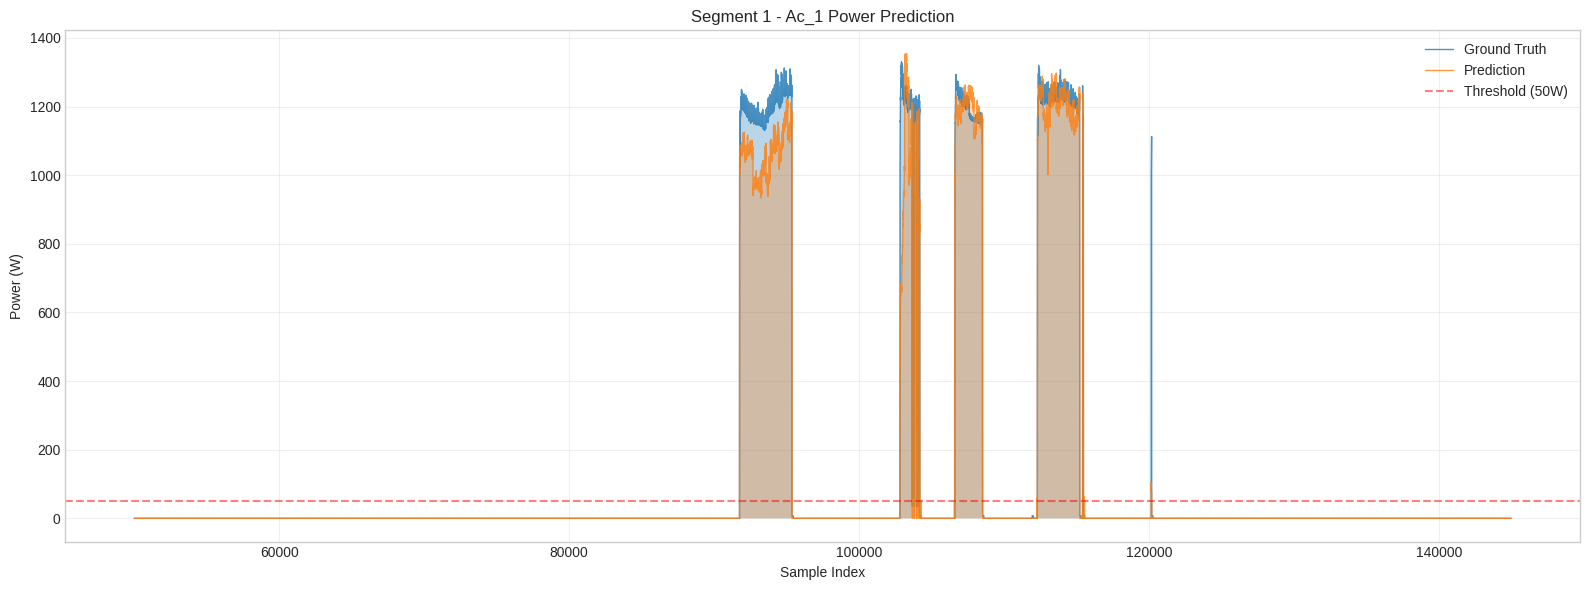

In [174]:
# Plot a segment of predictions vs ground truth
def plot_predictions(ground_truth, predictions, start_idx=0, length=5000, title=""):
    """Plot ground truth vs predictions for a segment."""
    end_idx = min(start_idx + length, len(ground_truth))

    fig, ax = plt.subplots(figsize=(16, 6))

    x = np.arange(start_idx, end_idx)
    ax.plot(x, ground_truth[start_idx:end_idx], label='Ground Truth', alpha=0.8, linewidth=1)
    ax.plot(x, predictions[start_idx:end_idx], label='Prediction', alpha=0.8, linewidth=1)
    ax.fill_between(x, 0, ground_truth[start_idx:end_idx], alpha=0.3)
    ax.fill_between(x, 0, predictions[start_idx:end_idx], alpha=0.3)

    ax.axhline(y=THRESHOLD, color='r', linestyle='--', label=f'Threshold ({THRESHOLD}W)', alpha=0.5)

    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Power (W)')
    ax.set_title(f'{title} - {APPLIANCE_NAME.capitalize()} Power Prediction')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# Plot several segments
fig = plot_predictions(ground_truth, predictions_clipped, start_idx=50000, length=95000, title="Segment 1")
plt.savefig(OUTPUT_DIR / 'figures' / 'prediction_segment1.png', dpi=150)
plt.show()

## 7. Save Results

In [172]:
# Create output directories
(OUTPUT_DIR / 'metrics').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)

# Save metrics to CSV
row = {
    'Model'             : MODEL_NAME,
    'Appliance'         : APPLIANCE_NAME,
    'Dataset'           : DATASET_NAME,
    'MAE'               : round(metrics['mae'],                                              4),
    'Precision_Complex' : round(metrics['precision_complex'], 4) if 'precision_complex' in metrics else '',
    'Recall_Complex'    : round(metrics['recall_complex'],    4) if 'recall_complex'    in metrics else '',
    'F1_Complex'        : round(metrics['f1_complex'],        4) if 'f1_complex'        in metrics else '',
    'Accuracy'          : round(metrics['accuracy'],                                         4),
    'GT_Energy_Wh'      : round(metrics['total_gt_energy_wh'],                               2),
    'Pred_Energy_Wh'    : round(metrics['total_pred_energy_wh'],                             2),
}

metrics_df   = pd.DataFrame([row])
metrics_path = OUTPUT_DIR / 'metrics' / f'{APPLIANCE_NAME}_results.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Metrics saved to: {metrics_path}")
metrics_df

Metrics saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/cnn_seq2seq_ac_1/metrics/ac_1_results.csv


,Model,Appliance,Dataset,MAE,Precision_Complex,Recall_Complex,F1_Complex,Accuracy,GT_Energy_Wh,Pred_Energy_Wh
0,cnn_seq2seq,ac_1,plegma,17.4235,0.8037,0.9516,0.8714,0.9848,63468.64,52700.101562


In [173]:
# Save predictions for further analysis
errors     = predictions_clipped - ground_truth
abs_errors = np.abs(errors)

pred_data = {
    'ground_truth_W': ground_truth,
    'prediction_W'  : predictions_clipped,
    'error'         : errors,
    'abs_error'     : abs_errors,
}

# Add status columns when min_on / min_off are available (PLEGMA dataset)
if MIN_ON is not None and MIN_OFF is not None:
    pred_data['ground_truth_status'] = compute_status(
        ground_truth, THRESHOLD, MIN_ON, MIN_OFF, MAX_LENGTH).astype(int)
    pred_data['predicted_status'] = compute_status(
        predictions_clipped, THRESHOLD, MIN_ON, MIN_OFF, MAX_LENGTH).astype(int)

predictions_df   = pd.DataFrame(pred_data)
predictions_path = OUTPUT_DIR / 'metrics' / f'{APPLIANCE_NAME}_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to: {predictions_path}")
print(f"Columns: {list(predictions_df.columns)}")


Predictions saved to: /content/drive/MyDrive/Colab Notebooks/ENERGIZE_TRAINING_FINAL/outputs/cnn_seq2seq_ac_1/metrics/ac_1_predictions.csv
Columns: ['ground_truth_W', 'prediction_W', 'error', 'abs_error', 'ground_truth_status', 'predicted_status']
